Explicit method converges: Convergence rate in discrete $L^2$ norm with respect to $h^2+k$: 1.0196188740225893
Implicit method converges: Convergence rate in discrete $L^2$ norm with respect to $h^2+k$: 1.0186834018017519


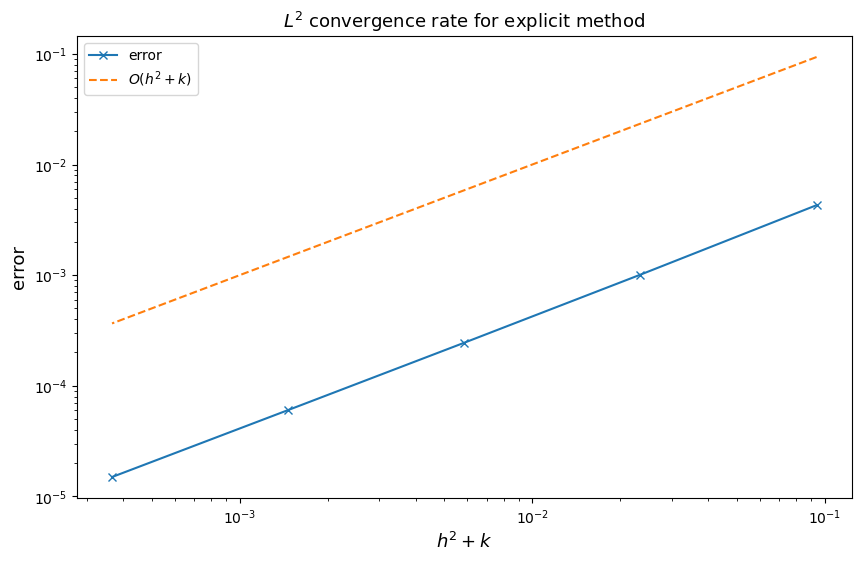

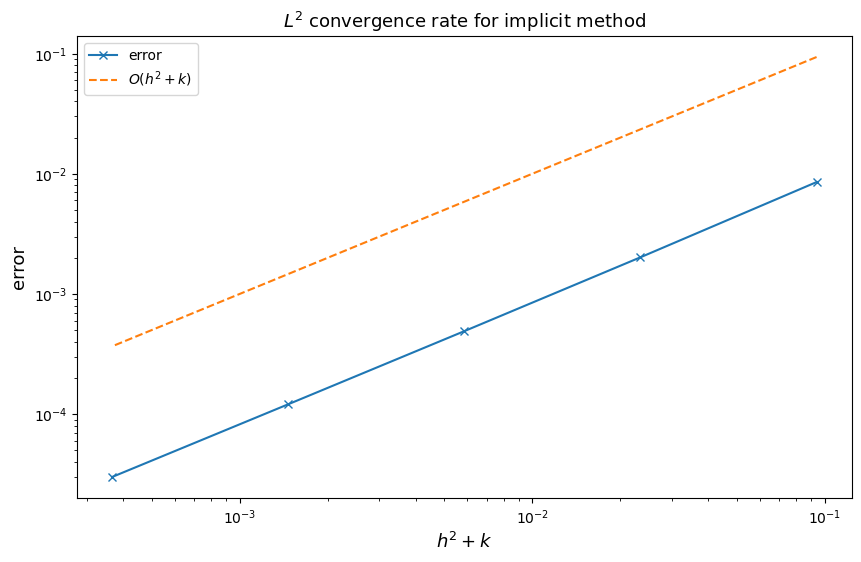

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as lin
import scipy.sparse as sp


# Set how floating-point errors are handled.
np.seterr(all='raise')


def initial_value(x):
    return np.sin(np.pi/2 * x)


#### exact solution at t=1 ####
def exact_solution_at_1(x):
    # todo 3 a)
    return np.exp(-(np.pi**2)/4) * np.sin(np.pi * x / 2)



#### numerical scheme ####
def eulerexplicit(N, M):
    # building auxiliary variables
    h = 1/N
    k = 1/M

    # First build u_i^0 = u0(ih)
    bc = np.linspace(0, 1, N + 1)[1:]
    bc = np.sin(np.pi * bc / 2)
    
    # Building the matrix G
    diagonal = np.ones(N)
    upper = np.ones(N-1)
    lower = np.ones(N-1)
    lower[-1] = 2.0
    G = sp.diags([lower, -2.0*diagonal, upper], [-1, 0, 1])

    # Getting the matrix C
    I = sp.eye(N)
    C = I + (k/(h**2))*G
    
    # Obtaining u(1,x)
    sol = lin.matrix_power(C.toarray(), M) @ bc
    return sol

def eulerimplicit(N, M):
    # building auxiliary variables
    h = 1/N
    k = 1/M

    # First build u_i^0 = u0(ih)
    bc = np.linspace(0, 1, N + 1)[1:]
    bc = np.sin(np.pi * bc / 2)
    
    # Building the matrix G
    diagonal = np.ones(N)
    upper = np.ones(N-1)
    lower = np.ones(N-1)
    lower[-1] = 2.0
    G = sp.diags([lower, -2.0*diagonal, upper], [-1, 0, 1])

    # Getting the matrix C
    I = sp.eye(N)
    C = I - (k/(h**2))*G
    u = bc
    # Obtaining u(1,x)
    for _ in range(M):
        u = lin.solve(C.toarray(), u)

    return u


#### error analysis ####
nb_samples = 5
N = np.array([2**i for i in range(2,7)])
M = np.array([(2*4**j) for j in range(2,7)]) # for question c
# M = np.array([(4**j) for j in range(2,7)]) for question d
l2errorexplicit = np.zeros(nb_samples)  # error vector for explicit method
l2errorimplicit = np.zeros(nb_samples)  # error vector for implicit method
h2k = 1 / (N ** 2) + 1 / M


#### Do not change any code below! ####
try:
    for i in range(nb_samples):
        l2errorexplicit[i] = (1 / N[i]) ** (1 / 2) * lin.norm(
            exact_solution_at_1(np.linspace(0, 1, N[i] + 1)[1:]) - eulerexplicit(N[i], M[i]), ord=2)
    conv_rate = np.polyfit(np.log(h2k), np.log(l2errorexplicit), deg=1)
    if np.isnan(conv_rate[0]):
        raise Exception("Error unbounded for explicit method. Plots not shown.")
    print("Explicit method converges: Convergence rate in discrete $L^2$ norm with respect to $h^2+k$: " + str(
        conv_rate[0]))
    plt.figure(figsize=[10, 6])
    plt.loglog(h2k, l2errorexplicit, '-x', label='error')
    plt.loglog(h2k, h2k, '--', label='$O(h^2+k)$')
    plt.title('$L^2$ convergence rate for explicit method', fontsize=13)
    plt.xlabel('$h^2+k$', fontsize=13)
    plt.ylabel('error', fontsize=13)
    plt.legend()
    plt.plot()
except Exception as e:
    print(f"Exception: {e}")

try:
    for i in range(nb_samples):
        l2errorimplicit[i] = (1 / N[i]) ** (1 / 2) * lin.norm(
            exact_solution_at_1(np.linspace(0, 1, N[i] + 1)[1:]) - eulerimplicit(N[i], M[i]), ord=2)
    conv_rate = np.polyfit(np.log(h2k), np.log(l2errorimplicit), deg=1)
    if np.isnan(conv_rate[0]):
        raise Exception("Error unbounded for implicit method. Plots not shown.")
    print("Implicit method converges: Convergence rate in discrete $L^2$ norm with respect to $h^2+k$: " + str(
        conv_rate[0]))
    plt.figure(figsize=[10, 6])
    plt.loglog(h2k, l2errorimplicit, '-x', label='error')
    plt.loglog(h2k, h2k, '--', label='$O(h^2+k)$')
    plt.title('$L^2$ convergence rate for implicit method', fontsize=13)
    plt.xlabel('$h^2+k$', fontsize=13)
    plt.ylabel('error', fontsize=13)
    plt.legend()
    plt.plot()
except Exception as e:
    print(f"Exception: {e}")

plt.show()